In [88]:
import csv
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model

## Rezolvarea problemei fara tool cu 2 parametrii

#### Pasul 1 - plot pt distributia datelor & plot pt “verificarea” liniaritatii (daca legatura intre y si x e una liniara)

In [89]:
def loadData(fileName, inputVariableName1, inputVariableName2, outputVariableName):
    data = []
    dataNames = []

    with open(fileName) as csv_file: # deschidem csv-ul
        csv_reader = csv.reader(csv_file, delimiter=',') # citim datele din csv
        line_count = 0 # suntem pe prima linie
        for row in csv_reader:
            if line_count == 0: # daca suntem pe prima linie, atunci inseamna ca suntem pe headerul tabelului
                dataNames = row # salvam numele coloanelor
            else: # daca nu suntem pe prima linie, atunci salvam datele de pe randul curent
                data.append(row)
            line_count += 1

        idx1 = dataNames.index(inputVariableName1)
        idx2 = dataNames.index(inputVariableName2)
        idxOutput = dataNames.index(outputVariableName)
        inputs1 = [float(row[idx1]) for row in data]
        inputs2 = [float(row[idx2]) for row in data]
        outputs = [float(row[idxOutput]) for row in data]

    return inputs1, inputs2, outputs

In [90]:
crtDir = os.getcwd() # luam calea catre folderul curent
filePath = os.path.join(crtDir, 'data', 'v2_world-happiness-report-2017.csv') # construim calea catre csv

inputs1, inputs2, outputs = loadData(filePath, 'Economy..GDP.per.Capita.', 'Freedom', 'Happiness.Score') # incarcam datele din csv
# inputs = normalizeData(inputs) # normalizam datele de intrare

print('input data: ', list(zip(inputs1, inputs2))[:5])
print('output data: ', outputs[:5])

input data:  [(1.616463184, 0.808231592), (1.482383013, 0.741191506), (1.48063302, 0.74031651), (1.564979553, 0.782489777), (1.443571925, 0.721785963)]
output data:  [7.537000179, 7.521999836, 7.504000187, 7.493999958, 7.468999863]


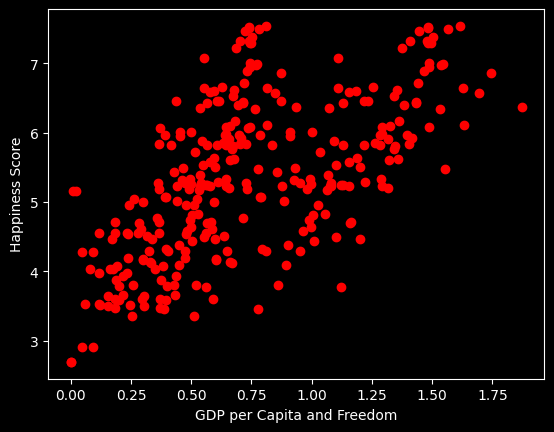

In [91]:
plt.plot(inputs1, outputs, 'ro') # afisam datele sub forma de puncte rosii
plt.plot(inputs2, outputs, 'ro') # afisam datele sub forma de puncte rosii
plt.xlabel('GDP per Capita and Freedom')
plt.ylabel('Happiness Score')
plt.show()


O clasificam intr-o problema de regresie liniara, deoarece se pare ca exista o legatura liniara intre cele doua variabile (se poate observa din plotul de mai sus).

<img src="images/regression.png" width="200">

#### Pasul 2 - impartire date pe train si validation

In [92]:
import random
# Impartim datele pe train si validation (80% train, 20% validation)
split = int(0.8 * len(inputs1))
indexes = [i for i in range(len(inputs1))]
random.shuffle(indexes)
trainSample = indexes[:split] # alegem aleator 80% din indexi pentru train
validationSample = indexes[split:] # restul de indexi vor fi pentru validation

trainInputs1 = [inputs1[i] for i in trainSample] # datele de intrare pentru train
trainInputs2 = [inputs2[i] for i in trainSample] # datele de intrare pentru train
trainOutputs = [outputs[i] for i in trainSample] # datele de iesire pentru train

validationInputs1 = [inputs1[i] for i in validationSample] # datele de intrare pentru validation
validationInputs2 = [inputs2[i] for i in validationSample] # datele de intrare pentru validation
validationOutputs = [outputs[i] for i in validationSample] # datele de iesire pentru validation

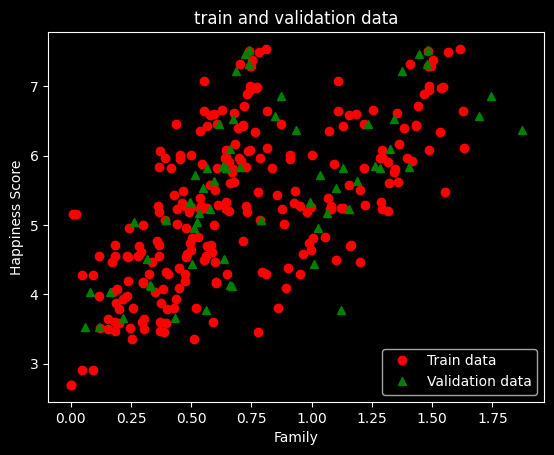

In [93]:
plt.plot(trainInputs1, trainOutputs, 'ro', label='Train data') # afisam datele de train sub forma de puncte rosii
plt.plot(trainInputs2, trainOutputs, 'ro') # afisam datele de train sub forma de puncte rosii
plt.plot(validationInputs1, validationOutputs, 'g^', label='Validation data') # afisam datele de validation sub forma de triunghiuri
# verzi
plt.plot(validationInputs2, validationOutputs, 'g^') # afisam datele de validation sub forma de triunghiuri verzi
plt.title('train and validation data')
plt.xlabel('Family')
plt.ylabel('Happiness Score')
plt.legend()
plt.show()

#### Pasul 3 - invatare model (fara tool generic si fara tool de least square)

**Metoda celor mai mici patrate**

Pentru cazul unei regresii multi-variate ($m$ atribute): $f(x,w) = w_0 + w_1 * x_1 + w_2 * x_2 + ... w_m * x_m$) si un set de date cu $n$ exemple:

$\boldsymbol{w} = (X^{T}X)^{-1}X^{T}{Y}$,
unde $X = (x^i_{j})$, $Y = (y^i)$, $i = 1, 2, ..., n$, $j = 1, 2, ..., m$.

In [94]:
X = []
for feature1, feature2 in zip(trainInputs1, trainInputs2):
    X.append([1, feature1, feature2]) # adaugam 1 pentru w0
Y = [[output] for output in trainOutputs]

def transpose(M):
    return [[M[j][i] for j in range(len(M))] for i in range(len(M[0]))]

def matmul(A, B):
    result = [[0 for _ in range(len(B[0]))] for _ in range(len(A))]
    for i in range(len(A)):
        for j in range(len(B[0])):
            for k in range(len(B)):
                result[i][j] += A[i][k] * B[k][j]
    return result

def inverse_3x3(M):
    det = (
        M[0][0]*(M[1][1]*M[2][2] - M[1][2]*M[2][1]) -
        M[0][1]*(M[1][0]*M[2][2] - M[1][2]*M[2][0]) +
        M[0][2]*(M[1][0]*M[2][1] - M[1][1]*M[2][0])
    )
    if det == 0:
        raise Exception("Matrice neinversabila")
    inv = [[0]*3 for _ in range(3)]

    inv[0][0] =  (M[1][1]*M[2][2] - M[1][2]*M[2][1]) / det
    inv[0][1] = -(M[0][1]*M[2][2] - M[0][2]*M[2][1]) / det
    inv[0][2] =  (M[0][1]*M[1][2] - M[0][2]*M[1][1]) / det

    inv[1][0] = -(M[1][0]*M[2][2] - M[1][2]*M[2][0]) / det
    inv[1][1] =  (M[0][0]*M[2][2] - M[0][2]*M[2][0]) / det
    inv[1][2] = -(M[0][0]*M[1][2] - M[0][2]*M[1][0]) / det

    inv[2][0] =  (M[1][0]*M[2][1] - M[1][1]*M[2][0]) / det
    inv[2][1] = -(M[0][0]*M[2][1] - M[0][1]*M[2][0]) / det
    inv[2][2] =  (M[0][0]*M[1][1] - M[0][1]*M[1][0]) / det

    return inv

XT = transpose(X)
XTX = matmul(XT, X)
XTX_inv = inverse_3x3(XTX)
XTY = matmul(XT, Y)
W = matmul(XTX_inv, XTY)

w0 = W[0][0]
w1 = W[1][0]
w2 = W[2][0]

print('The model learnt: y = ', w0, ' + ', w1, ' * GDP + ', w2, ' * Freedom')

The model learnt: y =  5.8972320556640625  +  3781689344.0  * GDP +  -7560232960.0  * Freedom


In [95]:
computedValidationOutputs = [w0 + w1 * input1 + w2 * input2 for input1, input2 in zip(trainInputs1, validationInputs2)]

#### Pasul 4 - calcul metrici de performanta (eroarea)

### Evaluarea performantei regresorului (a se vedea materialele din laboratorul 6)

- the absolute difference  (this is $L_1$ distance):
$$Error = \frac{1}{n} \times \sum_{i=1}^{n} |y^i - y^i_{computed}| = Mean Absolute Error (MAE)$$
- the square difference (this is the $L_2$ distance):
$$Error = \sqrt{\frac{1}{n} \times \sum_{i=1}^{n} (y^i - y^i_{computed}) ^ 2} = Root Mean Square Error (RMSE)$$

In [97]:
import math

mean_abs_error = 0.0
for t1, t2 in zip(validationOutputs, computedValidationOutputs):
    mean_abs_error += abs(t1 - t2)
mean_abs_error /= len(validationOutputs)
print('mean absolute error:', mean_abs_error)

mean_squared_error = 0.0
for t1, t2 in zip(validationOutputs, computedValidationOutputs):
    mean_squared_error += ((t1 - t2) ** 2)
mean_squared_error /= len(validationOutputs)
mean_squared_error = math.sqrt(mean_squared_error)
print('mean squared error:  ', mean_squared_error)

mean absolute error: 1977150866.4359758
mean squared error:   2303780294.2554126
